In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install transformers datasets evaluate accelerate scikit-learn
!pip uninstall torchvision -y

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 5.0 MB/s eta 0:00:00
  Attempting uninstall: cuda-toolkit
    Found existing installation: cuda-toolkit 13.0.2
    Uninstalling cuda-toolkit-13.0.2:
      Successfully uninstalled cuda-toolkit-13.0.2
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


In [ ]:
!pip install --upgrade torch torchvision torchaudio transformers accelerate pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/2

In [ ]:
!pip install transformers pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# ==========================================
# 1. ĐỌC DỮ LIỆU & CHUYỂN ĐỔI ĐỊNH DẠNG
# ==========================================
# ==========================================
# 1. ĐỌC DỮ LIỆU & CHUYỂN ĐỔI ĐỊNH DẠNG
# ==========================================
path = '/content/drive/MyDrive/DataAI/' # <-- SỬA ĐƯỜNG DẪN NẾU CẦN

df_train = pd.read_csv(path + 'train_processed.csv')[['processed_text', 'labels']].dropna()
df_val = pd.read_csv(path + 'val_processed.csv')[['processed_text', 'labels']].dropna()
df_test = pd.read_csv(path + 'test_processed.csv')[['processed_text', 'labels']].dropna()

# Ép kiểu văn bản
df_train['processed_text'] = df_train['processed_text'].astype(str)
df_val['processed_text'] = df_val['processed_text'].astype(str)
df_test['processed_text'] = df_test['processed_text'].astype(str)

# ---> CHÍNH LÀ 3 DÒNG NÀY: ÉP KIỂU NHÃN VỀ SỐ NGUYÊN (INT) <---
df_train['labels'] = df_train['labels'].astype(int)
df_val['labels'] = df_val['labels'].astype(int)
df_test['labels'] = df_test['labels'].astype(int)

raw_datasets = DatasetDict({
    'train': Dataset.from_pandas(df_train),
    'val': Dataset.from_pandas(df_val),
    'test': Dataset.from_pandas(df_test)
})
# ==========================================
# 2. KHỞI TẠO PHO-BERT & TOKENIZER
# ==========================================
model_name = "vinai/phobert-base-v2"

print("Đang tải Tokenizer và Model PhoBERT...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# ==========================================
# 3. TIỀN XỬ LÝ (BĂM TỪ) & DATA COLLATOR (CỨU TINH CHỐNG LỖI)
# ==========================================
def tokenize_function(examples):
    return tokenizer(examples["processed_text"], truncation=True, max_length=256)

print("Đang băm từ (Tokenizing) toàn bộ dữ liệu...")
tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

# Xóa các cột thừa (Bỏ hoàn toàn lệnh set_format("torch") gây lỗi)
tokenized_datasets = tokenized_datasets.remove_columns(["processed_text"])
if "__index_level_0__" in tokenized_datasets["train"].column_names:
    tokenized_datasets = tokenized_datasets.remove_columns(["__index_level_0__"])

# Dùng Data Collator để tự động chuyển dữ liệu thành Tensor chuẩn xác nhất
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ==========================================
# 4. THIẾT LẬP HÀM TÍNH ĐIỂM (METRICS)
# ==========================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1_macro': f1,
        'precision_macro': precision,
        'recall_macro': recall
    }

# ==========================================
# 5. CẤU HÌNH HUẤN LUYỆN (TRAINING)
# ==========================================
output_dir = path + "phobert_results"

training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["val"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,   # <-- TRUYỀN DATA COLLATOR VÀO ĐÂY
)

# ==========================================
# 6. BẮT ĐẦU TRAINING & LƯU KẾT QUẢ
# ==========================================
print("🚀 Bắt đầu huấn luyện PhoBERT...")
trainer.train()

print("\n📊 Đang đánh giá trên tập TEST...")
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"Kết quả PhoBERT trên tập Test: F1-Macro: {test_results['eval_f1_macro']:.4f}")

save_path = path + "phobert_final_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"✅ Đã lưu thư mục chứa Model và Tokenizer tại: {save_path}")

Đang tải Tokenizer và Model PhoBERT...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Đang băm từ (Tokenizing) toàn bộ dữ liệu...


Map:   0%|          | 0/5166 [00:00<?, ? examples/s]

...


📊 Đang đánh giá trên tập TEST...


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
0.661058,0.542503,3,0.791328,0.786642,0.785048,0.791208


Kết quả PhoBERT trên tập Test: F1-Macro: 0.7866


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Đã lưu thư mục chứa Model và Tokenizer tại: /content/drive/MyDrive/DataAI/phobert_final_model


1. Đang tải dữ liệu test...
2. Đang tải mô hình PhoBERT & Khởi động GPU...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

3. AI đang chấm điểm tập Test bằng CUDA...


  0%|          | 0/1476 [00:00<?, ?it/s]


4. Đang vẽ biểu đồ...


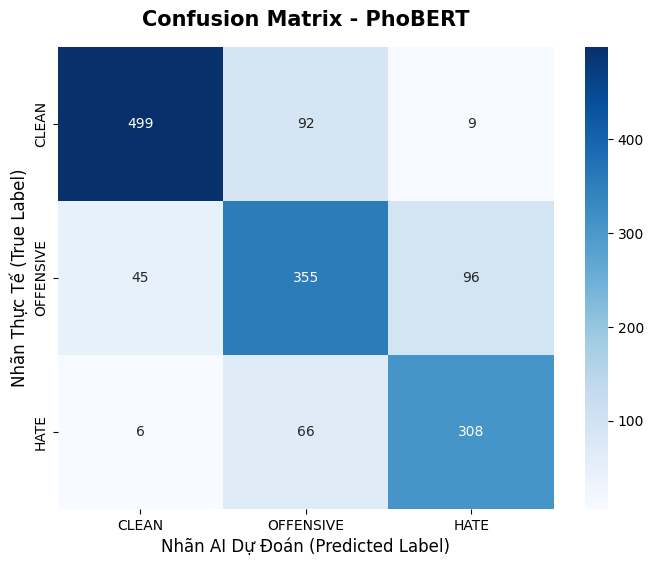


BÁO CÁO ĐỘ CHÍNH XÁC CHI TIẾT:
              precision    recall  f1-score   support

       CLEAN       0.91      0.83      0.87       600
   OFFENSIVE       0.69      0.72      0.70       496
        HATE       0.75      0.81      0.78       380

    accuracy                           0.79      1476
   macro avg       0.78      0.79      0.78      1476
weighted avg       0.79      0.79      0.79      1476



In [ ]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from pyvi import ViTokenizer
from tqdm import notebook

test_file = "/content/drive/MyDrive/DataAI/test_processed.csv"
model_path = "/content/drive/MyDrive/DataAI/phobert_final_model"
print("1. Đang tải dữ liệu test...")
df_test = pd.read_csv(test_file, usecols=[0, 1], encoding='utf-8-sig')
df_test.columns = ['processed_text', 'labels']
df_test = df_test.dropna()
df_test['labels'] = df_test['labels'].astype(int)

print("2. Đang tải mô hình PhoBERT & Khởi động GPU...")
tokenizer = AutoTokenizer.from_pretrained(model_path, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Bật GPU nếu có
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

y_true = df_test['labels'].tolist()
texts = df_test['processed_text'].astype(str).tolist()
y_pred = []

print(f"3. AI đang chấm điểm tập Test bằng {device.type.upper()}...")
for text in notebook.tqdm(texts):
    text_segmented = ViTokenizer.tokenize(text)
    inputs = tokenizer(text_segmented, return_tensors="pt", truncation=True, max_length=256).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=-1).item()
    y_pred.append(pred)

print("\n4. Đang vẽ biểu đồ...")
labels_name = ["CLEAN", "OFFENSIVE", "HATE"]
cm = confusion_matrix(y_true, y_pred)

# Vẽ hình
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_name, yticklabels=labels_name)
plt.title('Confusion Matrix - PhoBERT', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12)
plt.xlabel('Nhãn AI Dự Đoán (Predicted Label)', fontsize=12)

# Hiển thị trực tiếp trên màn hình Colab
plt.show()

print("\n" + "="*50)
print("BÁO CÁO ĐỘ CHÍNH XÁC CHI TIẾT:")
print("="*50)
print(classification_report(y_true, y_pred, target_names=labels_name))